In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_excel("../Dataset/ncr_ride_bookings.xlsx")

df.head()

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI


In [5]:
df.shape

(150000, 21)

In [6]:
df.columns

Index(['Date', 'Time', 'Booking ID', 'Booking Status', 'Customer ID',
       'Vehicle Type', 'Pickup Location', 'Drop Location', 'Avg VTAT',
       'Avg CTAT', 'Cancelled Rides by Customer',
       'Reason for cancelling by Customer', 'Cancelled Rides by Driver',
       'Driver Cancellation Reason', 'Incomplete Rides',
       'Incomplete Rides Reason', 'Booking Value', 'Ride Distance',
       'Driver Ratings', 'Customer Rating', 'Payment Method'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   Date                               150000 non-null  datetime64[ns]
 1   Time                               150000 non-null  object        
 2   Booking ID                         150000 non-null  object        
 3   Booking Status                     150000 non-null  object        
 4   Customer ID                        150000 non-null  object        
 5   Vehicle Type                       150000 non-null  object        
 6   Pickup Location                    150000 non-null  object        
 7   Drop Location                      150000 non-null  object        
 8   Avg VTAT                           139500 non-null  float64       
 9   Avg CTAT                           102000 non-null  float64       
 10  Cancelled Rides by C

In [8]:
df.describe(include='all')

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
count,150000,150000,150000,150000,150000,150000,150000,150000,139500.000000,102000.000000,...,10500,27000.0,27000,9000.0,9000,102000.000000,102000.000000,93000.000000,93000.000000,102000
unique,NaN,62910,148767,5,148788,7,176,176,NaN,NaN,...,5,NaN,4,NaN,3,NaN,NaN,NaN,NaN,5
top,NaN,17:44:57,"""CNR7908610""",Completed,"""CID4523979""",Auto,Khandsa,Ashram,NaN,NaN,...,Wrong Address,NaN,Customer related issue,NaN,Customer Demand,NaN,NaN,NaN,NaN,UPI
freq,NaN,16,3,93000,3,37419,949,936,NaN,NaN,...,2362,NaN,6837,NaN,3040,NaN,NaN,NaN,NaN,45909
mean,2024-06-30 16:42:40.320000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.456352,29.149636,...,NaN,1.0,NaN,1.0,NaN,508.295912,24.637012,4.230992,4.404584,NaN
min,2024-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,10.000000,...,NaN,1.0,NaN,1.0,NaN,50.000000,1.000000,3.000000,3.000000,NaN
25%,2024-03-31 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.300000,21.600000,...,NaN,1.0,NaN,1.0,NaN,234.000000,12.460000,4.100000,4.200000,NaN
50%,2024-07-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.300000,28.800000,...,NaN,1.0,NaN,1.0,NaN,414.000000,23.720000,4.300000,4.500000,NaN
75%,2024-09-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.300000,36.800000,...,NaN,1.0,NaN,1.0,NaN,689.000000,36.820000,4.600000,4.800000,NaN
max,2024-12-30 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,45.000000,...,NaN,1.0,NaN,1.0,NaN,4277.000000,50.000000,5.000000,5.000000,NaN


In [9]:
df.isnull().sum()

Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64

In [10]:
df.duplicated().sum()

0

In [11]:
df["Booking Status"].value_counts()

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64

In [12]:
df.dtypes

Date                                 datetime64[ns]
Time                                         object
Booking ID                                   object
Booking Status                               object
Customer ID                                  object
Vehicle Type                                 object
Pickup Location                              object
Drop Location                                object
Avg VTAT                                    float64
Avg CTAT                                    float64
Cancelled Rides by Customer                 float64
Reason for cancelling by Customer            object
Cancelled Rides by Driver                   float64
Driver Cancellation Reason                   object
Incomplete Rides                            float64
Incomplete Rides Reason                      object
Booking Value                               float64
Ride Distance                               float64
Driver Ratings                              float64
Customer Rat

In [13]:
df["Time"] = pd.to_datetime(df["Time"]).dt.time

TypeError: <class 'datetime.time'> is not convertible to datetime, at position 0

In [ ]:
type(df["Time"].iloc[0])

datetime.time

In [ ]:
df["Hour"] = df["Time"].apply(lambda x: x.hour)

In [ ]:
df[["Time", "Hour"]].head()

,Time,Hour
0,12:29:38,12
1,18:01:39,18
2,08:56:10,8
3,17:17:25,17
4,22:08:00,22


In [ ]:
df["Month"] = df["Date"].dt.month_name()
df["Day"] = df["Date"].dt.day_name()

In [ ]:
def time_slot(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df["Time Slot"] = df["Hour"].apply(time_slot)

In [31]:
# Month
df["Month"] = df["Date"].dt.month_name()

# Day of Week
df["Day"] = df["Date"].dt.day_name()

# Hour
df["Hour"] = df["Time"].apply(lambda x: x.hour)

# Time Slot
def get_time_slot(hour):
    if 0 <= hour < 6:
        return "Late Night"
    elif 6 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df["Time Slot"] = df["Hour"].apply(get_time_slot)

print("Feature engineering completed successfully!")

Feature engineering completed successfully!


# Exploratory Data Analysis (EDA)
## EDA 1: Booking Status Distribution

### Business Question
How are ride bookings distributed across different booking statuses?

### Objective
Analyze the proportion of completed, cancelled, and incomplete rides to understand the operational performance of the ride-sharing service.

### Expected Insight
- Identify the percentage of successfully completed rides.
- Compare driver cancellations with customer cancellations.
- Evaluate the overall ride completion rate.

In [14]:
df = pd.read_excel("../Dataset/ncr_ride_bookings.xlsx")

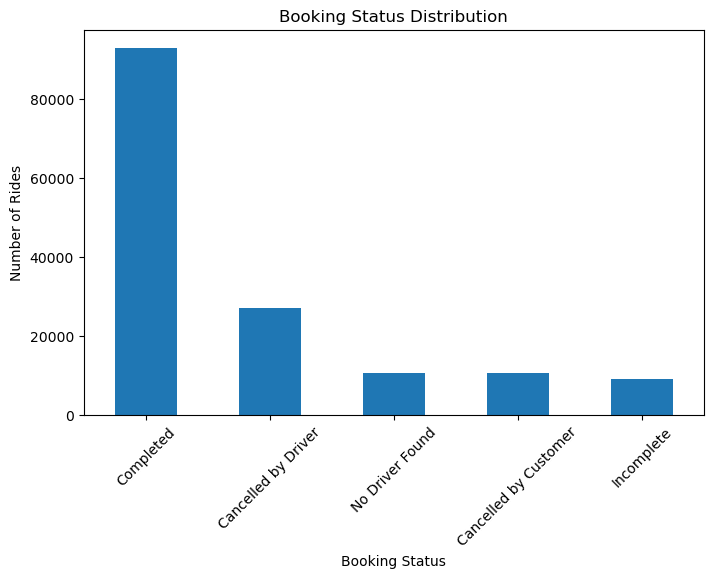

In [16]:
status = df["Booking Status"].value_counts()

plt.figure(figsize=(8,5))
status.plot(kind="bar")
plt.title("Booking Status Distribution")
plt.xlabel("Booking Status")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

## EDA 2: Vehicle Type Distribution

## Business Question
Which vehicle type receives the highest number of bookings?

### Objective
Analyze customer preferences for different vehicle categories and identify the most frequently booked vehicle type.

### Expected Insight
- Most preferred vehicle category.
- Least preferred vehicle category.
- Demand distribution across vehicle types.

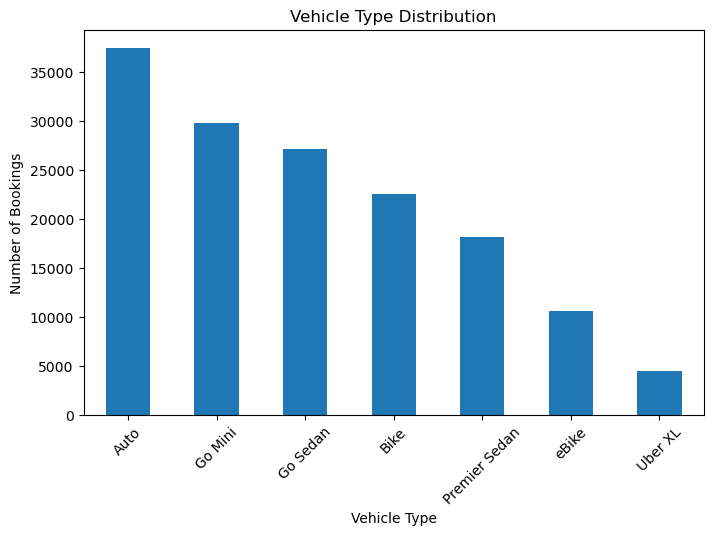

In [18]:
vehicle = df["Vehicle Type"].value_counts()

plt.figure(figsize=(8,5))
vehicle.plot(kind="bar")
plt.title("Vehicle Type Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

## EDA 3: Revenue by Vehicle Type

### Business Question
Which vehicle category contributes the highest revenue?

### Objective
Evaluate revenue generated by each vehicle type to identify the most profitable service category.

### Expected Insight
- Highest revenue-generating vehicle type.
- Revenue comparison among different vehicle categories.
- Business opportunities for increasing profitability.

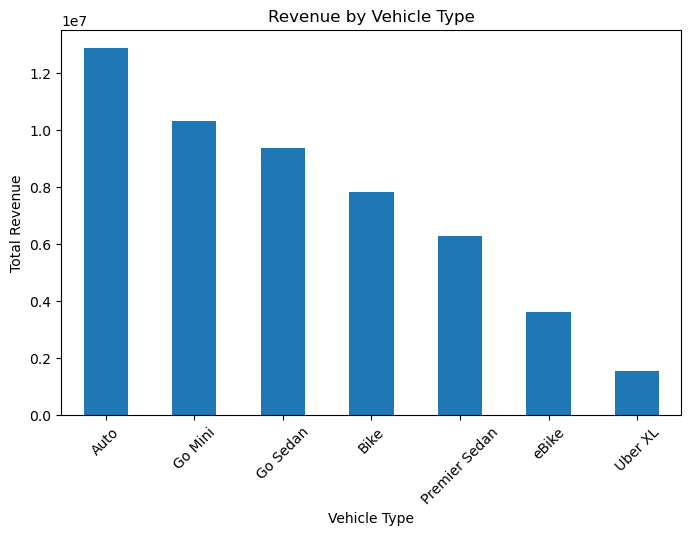

In [19]:
revenue = df.groupby("Vehicle Type")["Booking Value"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
revenue.plot(kind="bar")
plt.title("Revenue by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

## EDA 4: Payment Method Distribution

### Business Question
Which payment method is most commonly used by customers?

### Objective
Understand customer payment preferences to improve payment services and promotional strategies.

### Expected Insight
- Most preferred payment method.
- Digital versus cash payment usage.
- Customer payment behavior.

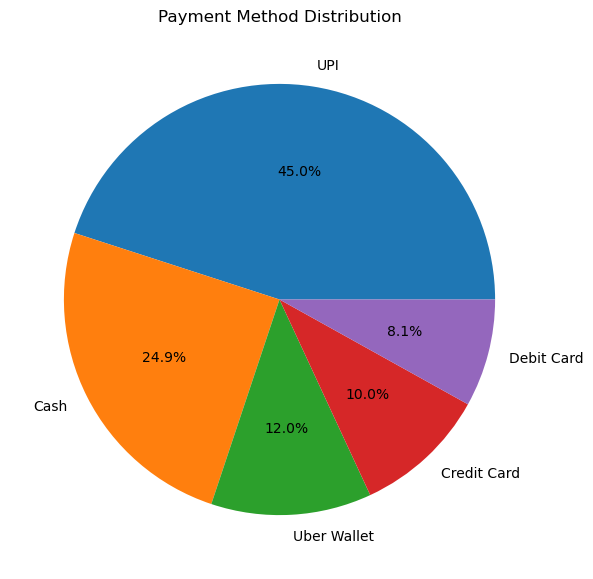

In [20]:
payment = df["Payment Method"].value_counts()

plt.figure(figsize=(7,7))
payment.plot(kind="pie", autopct="%1.1f%%")
plt.ylabel("")
plt.title("Payment Method Distribution")
plt.show()

## EDA 5: Booking Trend by Hour

### Business Question
At what hour of the day are ride bookings highest?

### Objective
Identify peak booking hours to optimize driver availability and reduce customer waiting time.

### Expected Insight
- Peak demand hours.
- Low-demand hours.
- Daily booking pattern.

In [22]:
df["Hour"] = df["Time"].apply(lambda x: x.hour)

In [23]:
df[["Time", "Hour"]].head()

,Time,Hour
0,12:29:38,12
1,18:01:39,18
2,08:56:10,8
3,17:17:25,17
4,22:08:00,22


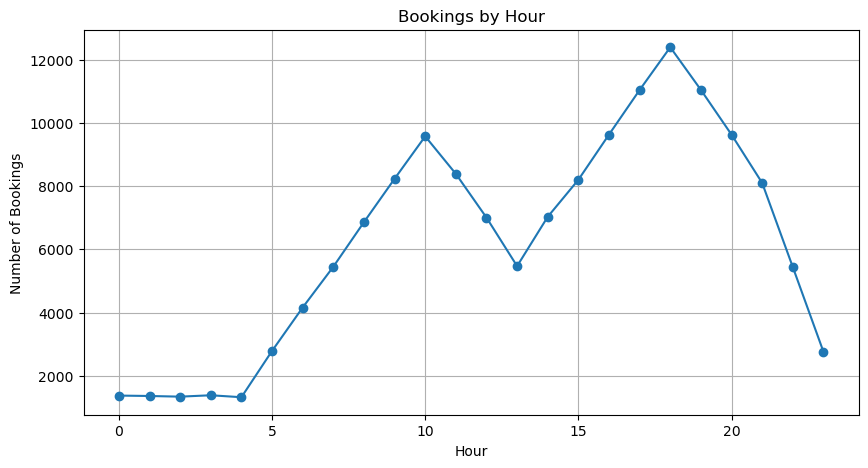

In [24]:
hourly = df.groupby("Hour").size()

plt.figure(figsize=(10,5))
hourly.plot(kind="line", marker="o")
plt.title("Bookings by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Bookings")
plt.grid(True)
plt.show()

## EDA 6: Bookings by Day of Week

### Business Question
Which day of the week experiences the highest ride demand?

### Objective
Analyze weekly booking trends to support workforce planning and promotional campaigns.

### Expected Insight
- Busiest day of the week.
- Lowest booking day.
- Weekly demand pattern.

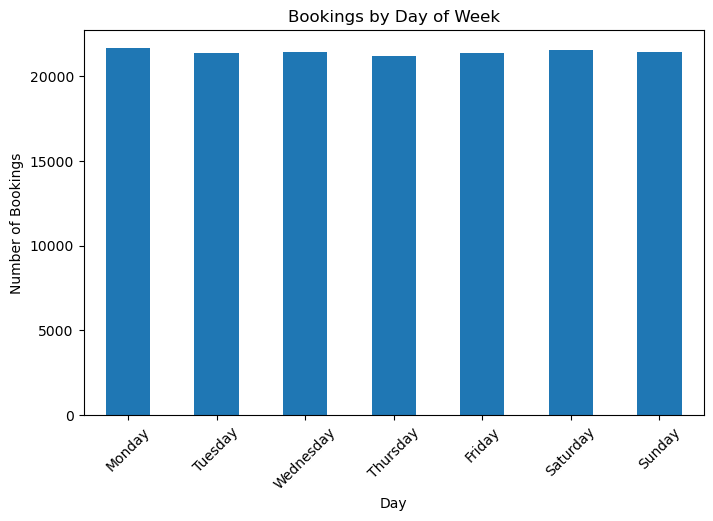

In [32]:
day_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

daywise = df["Day"].value_counts().reindex(day_order)

plt.figure(figsize=(8,5))
daywise.plot(kind="bar")
plt.title("Bookings by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

## EDA 7: Bookings by Time Slot

### Business Question
Which time slot has the highest ride demand?

### Objective
Analyze booking patterns across different time periods of the day to improve resource allocation.

### Expected Insight
- Peak demand time slot.
- Lowest demand time slot.
- Customer travel behavior throughout the day.

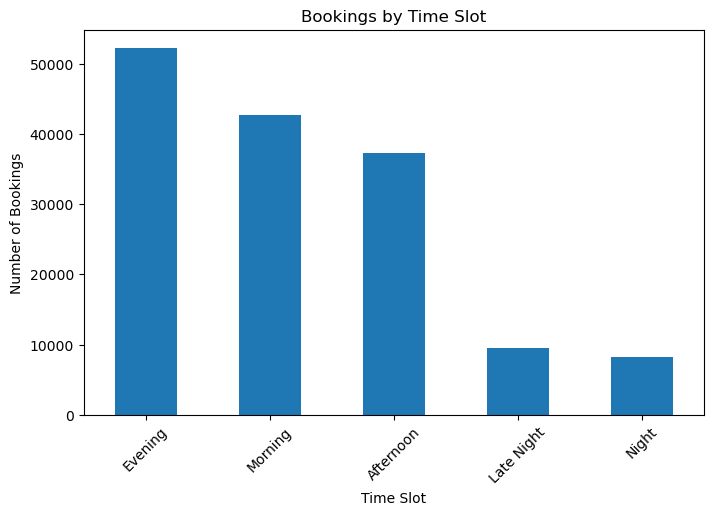

In [33]:
slot = df["Time Slot"].value_counts()

plt.figure(figsize=(8,5))
slot.plot(kind="bar")
plt.title("Bookings by Time Slot")
plt.xlabel("Time Slot")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

## EDA 8: Booking Status Analysis

### Business Question
How are bookings distributed across different booking statuses?

### Objective
Analyze ride outcomes to understand operational efficiency and identify areas for improvement.

### Expected Insight
- Percentage of completed rides.
- Driver vs. customer cancellations.
- Scope for reducing ride failures.

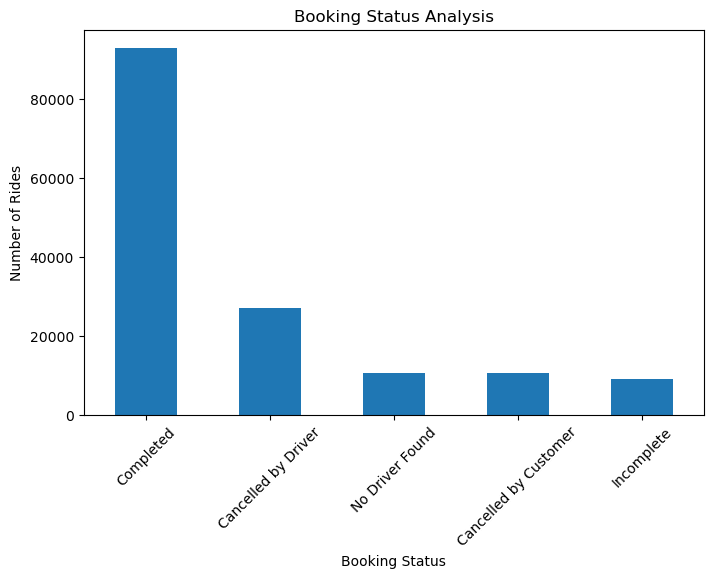

In [35]:
cancel = df["Booking Status"].value_counts()

plt.figure(figsize=(8,5))
cancel.plot(kind="bar")
plt.title("Booking Status Analysis")
plt.xlabel("Booking Status")
plt.ylabel("Number of Rides")
plt.xticks(rotation=45)
plt.show()

## EDA 9: Average Booking Value by Vehicle Type

### Business Question
Which vehicle type has the highest average booking value?

### Objective
Compare the average fare across vehicle categories to identify premium and budget services.

### Expected Insight
- Vehicle category with the highest average booking value.
- Comparison of fare patterns across vehicle types.
- Revenue optimization opportunities.

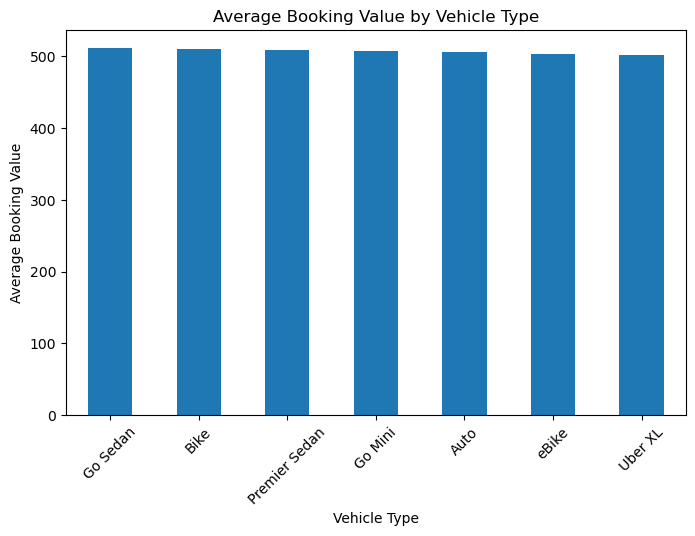

In [36]:
avg_booking = df.groupby("Vehicle Type")["Booking Value"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
avg_booking.plot(kind="bar")
plt.title("Average Booking Value by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Booking Value")
plt.xticks(rotation=45)
plt.show()

## EDA 10: Average Ride Distance by Vehicle Type

### Business Question
Which vehicle type is generally used for longer trips?

### Objective
Analyze average ride distance for each vehicle category to understand customer travel patterns.

### Expected Insight
- Vehicle types preferred for long-distance travel.
- Comparison of average trip lengths.
- Demand characteristics across services.

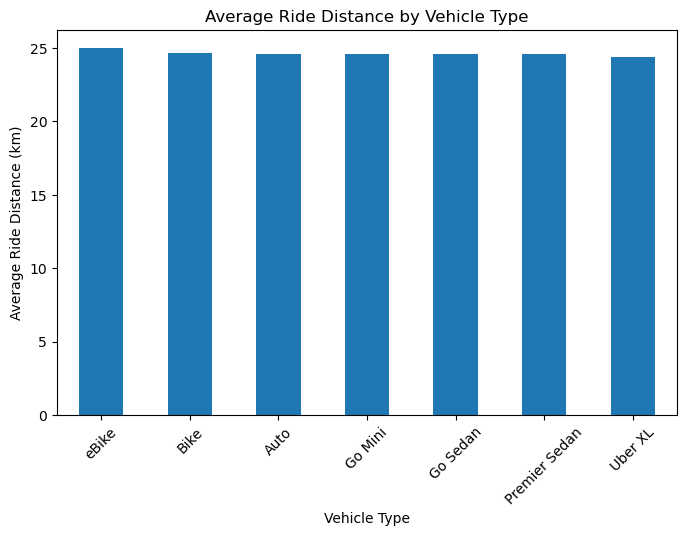

In [37]:
distance = df.groupby("Vehicle Type")["Ride Distance"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
distance.plot(kind="bar")
plt.title("Average Ride Distance by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average Ride Distance (km)")
plt.xticks(rotation=45)
plt.show()

## EDA 11: Top 10 Pickup Locations

### Business Question
Which pickup locations generate the highest ride demand?

### Objective
Identify high-demand pickup areas to support driver allocation and operational planning.

### Expected Insight
- Most frequently used pickup locations.
- High-demand zones.
- Opportunities to improve driver availability.

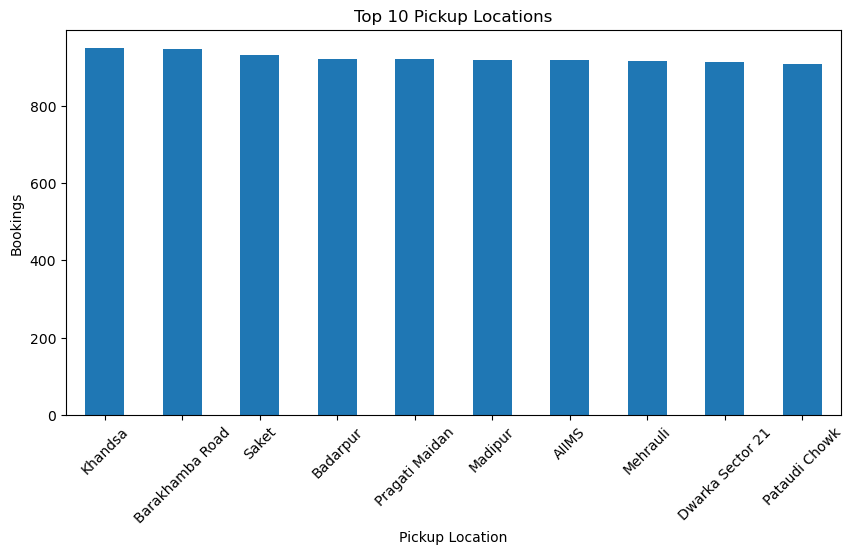

In [38]:
pickup = df["Pickup Location"].value_counts().head(10)

plt.figure(figsize=(10,5))
pickup.plot(kind="bar")
plt.title("Top 10 Pickup Locations")
plt.xlabel("Pickup Location")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()


## EDA 12: Top 10 Drop Locations

### Business Question
Which destinations receive the highest number of rides?

### Objective
Analyze popular drop locations to understand customer travel patterns and destination demand.

### Expected Insight
- Most common destinations.
- Frequently traveled routes.
- High-demand service areas.

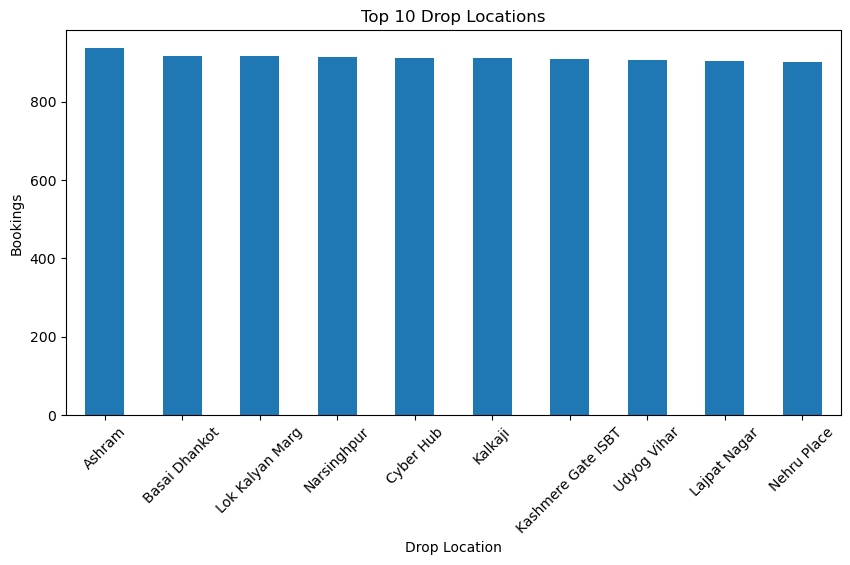

In [39]:
drop = df["Drop Location"].value_counts().head(10)

plt.figure(figsize=(10,5))
drop.plot(kind="bar")
plt.title("Top 10 Drop Locations")
plt.xlabel("Drop Location")
plt.ylabel("Bookings")
plt.xticks(rotation=45)
plt.show()

## EDA 13: Driver Ratings Distribution

### Business Question
How are driver ratings distributed?

### Objective
Evaluate driver performance using customer ratings to identify overall service quality.

### Expected Insight
- Average driver rating.
- Distribution of high and low ratings.
- Overall driver performance.

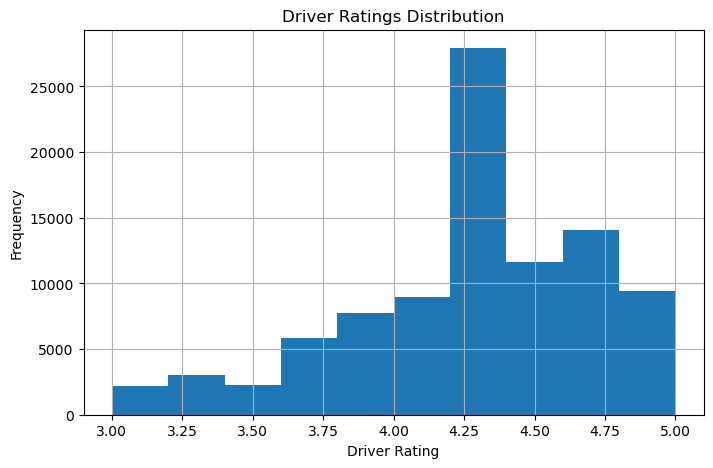

In [40]:
plt.figure(figsize=(8,5))
df["Driver Ratings"].dropna().hist(bins=10)
plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")
plt.ylabel("Frequency")
plt.show()

## EDA 14: Customer Ratings Distribution

### Business Question
How are customer ratings distributed?

### Objective
Analyze customer ratings to understand user satisfaction and ride experience.

### Expected Insight
- Overall customer satisfaction.
- Rating distribution.
- Service improvement opportunities.

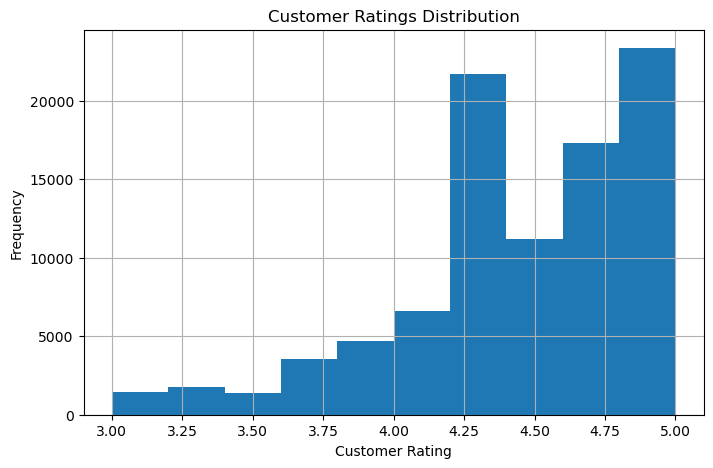

In [41]:
plt.figure(figsize=(8,5))
df["Customer Rating"].dropna().hist(bins=10)
plt.title("Customer Ratings Distribution")
plt.xlabel("Customer Rating")
plt.ylabel("Frequency")
plt.show()

## EDA 15: Monthly Revenue Trend

### Business Question
How does revenue change over different months?

### Objective
Analyze monthly revenue trends to identify seasonal demand and business performance.

### Expected Insight
- Highest revenue-generating month.
- Seasonal booking patterns.
- Revenue growth opportunities.

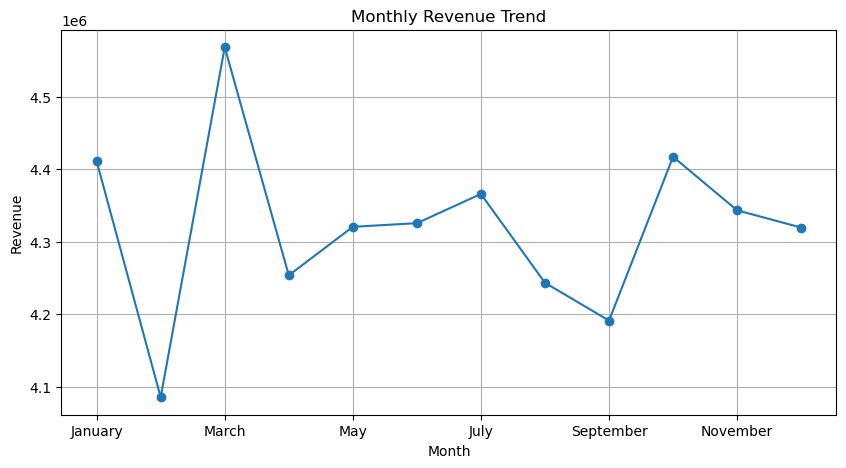

In [42]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = (
    df.groupby("Month")["Booking Value"]
      .sum()
      .reindex(month_order)
)

plt.figure(figsize=(10,5))
monthly_revenue.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

# Key Business Insights

### Summary of Findings

This section summarizes the most important insights obtained from the exploratory data analysis.

- Most rides were successfully completed, indicating strong operational performance.
- Driver cancellations were higher than customer cancellations, highlighting an opportunity to improve driver availability.
- Certain vehicle categories generated significantly higher revenue than others.
- Ride demand was concentrated during specific hours and time slots.
- A few pickup and drop locations accounted for a large share of total bookings.
- Customer and driver ratings indicated generally positive service quality.
- Monthly revenue trends revealed fluctuations that can support demand forecasting and business planning.

In [43]:
df.to_csv("../Dataset/ride_cleaned.csv", index=False)